# Spotify Popularity Research: Multiple Regression and kNN Regression

This notebook uses the Kaggle-derived Spotify tracks data already in this project to study how available track variables relate to popularity and how well a k-nearest-neighbors regression model can predict popularity.

Research flow:

1. Load the cleaned Kaggle dataset.
2. Split the data into an 80% training set and a 20% testing set.
3. Fit a multiple-variable OLS regression on the training set to estimate relationships with popularity.
4. Train a kNN regression model on the training set.
5. Evaluate the kNN model on the held-out testing set.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 140)


## 1. Load the Dataset

The project contains both the original Kaggle CSV, dataset.csv, and the cleaned version, cleaned.csv. This notebook uses cleaned.csv because it removes duplicate track IDs, drops invalid rows, and adds duration_min for readability while preserving the Kaggle-provided audio features.


In [2]:
DATA_PATH = Path('cleaned.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('dataset.csv')

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

if 'duration_min' not in df.columns and 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60_000

if df['explicit'].dtype == bool:
    df['explicit'] = df['explicit'].astype(int)

print(f'Loaded {DATA_PATH.name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing values: {int(df.isna().sum().sum()):,}')
print(f'Popularity range: {df["popularity"].min()} to {df["popularity"].max()}')
display(df.head())


Loaded cleaned.csv: 89,740 rows x 21 columns
Missing values: 0
Popularity range: 0 to 100


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,0,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance,2.62
1,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,0,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop,3.32
2,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton,2.71
3,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,1,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop,2.92
4,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,0,0.650,0.715,5,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,latino,4.06


## 2. Select Research Variables

For regression, identifiers and free-text fields such as track_id, track_name, album_name, and artists are excluded because they do not behave like stable numeric variables. duration_ms is excluded because duration_min contains the same information in a more readable unit.

The OLS regression includes numeric/audio variables plus track_genre as categorical dummy variables. The kNN model uses the numeric/audio variables only because distance-based models require a meaningful numeric distance; one-hot genre distances can dominate the neighborhood calculation without representing real musical similarity.


In [3]:
numeric_features = [
    'duration_min', 'explicit', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature',
]

categorical_features = ['track_genre']
target = 'popularity'

research_columns = numeric_features + categorical_features + [target]
model_df = df[research_columns].dropna().copy()

X = model_df[numeric_features + categorical_features]
y = model_df[target].astype(float)

print(f'Research dataset after dropping missing modeling values: {model_df.shape[0]:,} rows')
print(f'Numeric predictors for kNN: {len(numeric_features)}')
print(f'Genres included in OLS regression: {model_df["track_genre"].nunique()}')


Research dataset after dropping missing modeling values: 89,740 rows
Numeric predictors for kNN: 14
Genres included in OLS regression: 114


## 3. Split into 80% Training and 20% Testing Sets

All relationship discovery and model fitting happen on the training set. The test set is held back until the final kNN evaluation.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]:,} rows ({X_train.shape[0] / len(X):.1%})')
print(f'Testing set:  {X_test.shape[0]:,} rows ({X_test.shape[0] / len(X):.1%})')
print(f'Training target mean: {y_train.mean():.2f}')
print(f'Testing target mean:  {y_test.mean():.2f}')


Training set: 71,792 rows (80.0%)
Testing set:  17,948 rows (20.0%)
Training target mean: 33.20
Testing target mean:  33.24


## 4. Multiple-Variable Regression on the Training Set

This section fits an OLS multiple regression using only the training set. Numeric variables are standardized first, so their coefficients are comparable: a coefficient is the expected popularity-point change for a one-standard-deviation increase in that predictor, holding the other variables constant.

Genre is included through dummy variables. Its coefficients are interpreted relative to the omitted baseline genre.


In [5]:
scaler_for_ols = StandardScaler()
X_train_numeric_scaled = pd.DataFrame(
    scaler_for_ols.fit_transform(X_train[numeric_features]),
    columns=numeric_features,
    index=X_train.index,
)

X_train_genre_dummies = pd.get_dummies(
    X_train['track_genre'], prefix='genre', drop_first=True, dtype=float
)

X_train_ols = pd.concat([X_train_numeric_scaled, X_train_genre_dummies], axis=1)
X_train_ols = sm.add_constant(X_train_ols)

ols_model = sm.OLS(y_train.astype(float), X_train_ols.astype(float)).fit()

print(f'OLS training R^2:          {ols_model.rsquared:.3f}')
print(f'OLS adjusted training R^2: {ols_model.rsquared_adj:.3f}')
print(f'Number of predictors:      {int(ols_model.df_model):,}')


OLS training R^2:          0.339
OLS adjusted training R^2: 0.338
Number of predictors:      127


In [6]:
numeric_relation = (
    pd.DataFrame({
        'feature': numeric_features,
        'coefficient': ols_model.params[numeric_features].values,
        'p_value': ols_model.pvalues[numeric_features].values,
    })
    .assign(abs_coefficient=lambda data: data['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
    .drop(columns='abs_coefficient')
)

print('Standardized numeric-feature coefficients, sorted by absolute size:')
display(numeric_relation.style.format({'coefficient': '{:.3f}', 'p_value': '{:.2e}'}))


Standardized numeric-feature coefficients, sorted by absolute size:


,feature,coefficient,p_value
11,valence,-1.000,2.46e-29
2,danceability,0.882,1.29e-20
3,energy,-0.671,2.01e-06
1,explicit,0.579,4.65e-16
7,speechiness,-0.476,1.27e-07
6,mode,-0.409,4.36e-10
8,acousticness,-0.338,2.05e-03
5,loudness,0.326,9.55e-03
10,liveness,-0.303,1.93e-05
9,instrumentalness,-0.296,1.27e-03


In [7]:
genre_params = ols_model.params.filter(like='genre_').copy()
genre_effects = (
    genre_params.rename_axis('genre_dummy')
    .reset_index(name='coefficient_vs_baseline')
    .assign(genre=lambda data: data['genre_dummy'].str.replace('genre_', '', regex=False))
    [['genre', 'coefficient_vs_baseline']]
)

baseline_genre = sorted(X_train['track_genre'].unique())[0]
print(f'Baseline genre omitted from dummy variables: {baseline_genre}')
print('Most positive genre coefficients relative to baseline:')
display(genre_effects.sort_values('coefficient_vs_baseline', ascending=False).head(10).style.format({'coefficient_vs_baseline': '{:.2f}'}))
print('Most negative genre coefficients relative to baseline:')
display(genre_effects.sort_values('coefficient_vs_baseline').head(10).style.format({'coefficient_vs_baseline': '{:.2f}'}))


Baseline genre omitted from dummy variables: acoustic
Most positive genre coefficients relative to baseline:


,genre,coefficient_vs_baseline
64,k-pop,17.19
80,pop-film,15.20
14,chill,10.71
46,hard-rock,8.86
43,grunge,8.55
93,sad,8.39
98,singer-songwriter,7.95
54,indian,7.51
96,sertanejo,7.06
79,pop,6.93


Most negative genre coefficients relative to baseline:


,genre,coefficient_vs_baseline
58,iranian,-38.77
92,romance,-38.31
66,latin,-33.78
63,jazz,-31.03
23,detroit-techno,-30.94
12,chicago-house,-30.23
15,classical,-28.28
65,kids,-27.15
87,reggae,-26.25
53,idm,-26.11


### Regression Reading Guide

The OLS model is useful for interpretation, not as the final prediction model here. Positive coefficients mean higher expected popularity after controlling for the other variables in the model; negative coefficients mean lower expected popularity. Small p-values can appear even for weak practical effects because this dataset has many observations.


## 5. Tune kNN Regression on the Training Set

kNN regression predicts a track's popularity by averaging the popularity of nearby tracks in feature space. Because kNN is distance-based, all numeric predictors are standardized.

A validation split is carved out from the training set to choose k; the untouched 20% test set remains reserved for final evaluation.


In [8]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train[numeric_features], y_train, test_size=0.20, random_state=RANDOM_STATE
)

candidate_k = [3, 5, 11, 21, 31]
validation_rows = []

for k in candidate_k:
    candidate_model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance')),
    ])
    candidate_model.fit(X_fit, y_fit)
    val_pred = candidate_model.predict(X_val)
    validation_rows.append({
        'k': k,
        'validation_r2': r2_score(y_val, val_pred),
        'validation_mae': mean_absolute_error(y_val, val_pred),
        'validation_rmse': np.sqrt(mean_squared_error(y_val, val_pred)),
    })

validation_results = pd.DataFrame(validation_rows).sort_values('validation_mae')
best_k = int(validation_results.iloc[0]['k'])

print(f'Best k by validation MAE: {best_k}')
display(validation_results.style.format({
    'validation_r2': '{:.3f}',
    'validation_mae': '{:.2f}',
    'validation_rmse': '{:.2f}',
}))


Best k by validation MAE: 31


,k,validation_r2,validation_mae,validation_rmse
4,31,0.168,14.13,18.60
3,21,0.151,14.22,18.78
2,11,0.113,14.47,19.20
1,5,0.026,15.09,20.12
0,3,-0.072,15.73,21.11


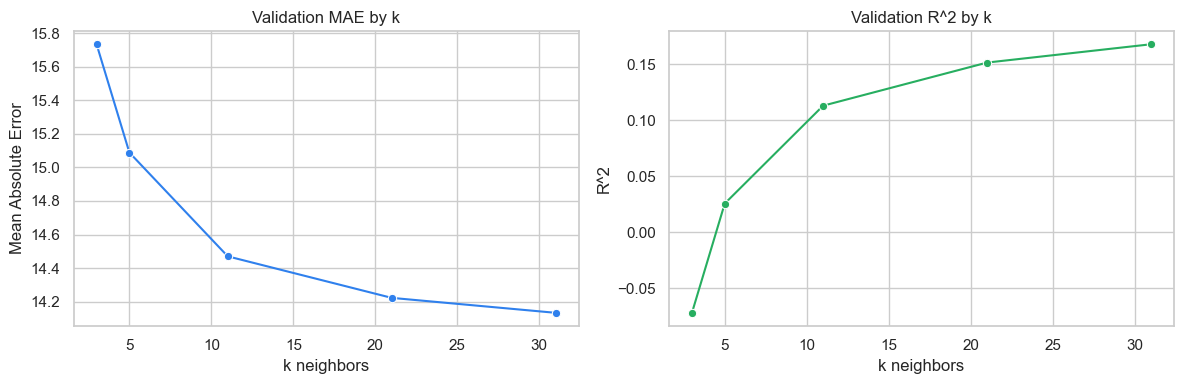

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_df = validation_results.sort_values('k')

sns.lineplot(data=plot_df, x='k', y='validation_mae', marker='o', ax=axes[0], color='#2F80ED')
axes[0].set_title('Validation MAE by k')
axes[0].set_xlabel('k neighbors')
axes[0].set_ylabel('Mean Absolute Error')

sns.lineplot(data=plot_df, x='k', y='validation_r2', marker='o', ax=axes[1], color='#27AE60')
axes[1].set_title('Validation R^2 by k')
axes[1].set_xlabel('k neighbors')
axes[1].set_ylabel('R^2')

plt.tight_layout()
plt.show()


## 6. Train Final kNN Model and Evaluate on the 20% Test Set

The final kNN model is trained on the full 80% training set using the selected k, then evaluated once on the 20% test set. For regression, there is no single classification-style accuracy score, so this notebook reports R², MAE, RMSE, and the share of predictions within 10 and 20 popularity points.


In [10]:
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_k, weights='distance')),
])

knn_model.fit(X_train[numeric_features], y_train)
test_pred = knn_model.predict(X_test[numeric_features])

absolute_errors = np.abs(y_test - test_pred)

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train[numeric_features], y_train)
baseline_pred = baseline.predict(X_test[numeric_features])

metrics = pd.DataFrame([
    {
        'model': f'kNN regression (k={best_k})',
        'test_r2': r2_score(y_test, test_pred),
        'test_mae': mean_absolute_error(y_test, test_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
        'within_10_points': np.mean(absolute_errors <= 10),
        'within_20_points': np.mean(absolute_errors <= 20),
    },
    {
        'model': 'mean baseline',
        'test_r2': r2_score(y_test, baseline_pred),
        'test_mae': mean_absolute_error(y_test, baseline_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, baseline_pred)),
        'within_10_points': np.mean(np.abs(y_test - baseline_pred) <= 10),
        'within_20_points': np.mean(np.abs(y_test - baseline_pred) <= 20),
    },
])

display(metrics.style.format({
    'test_r2': '{:.3f}',
    'test_mae': '{:.2f}',
    'test_rmse': '{:.2f}',
    'within_10_points': '{:.1%}',
    'within_20_points': '{:.1%}',
}))


,model,test_r2,test_mae,test_rmse,within_10_points,within_20_points
0,kNN regression (k=31),0.191,13.95,18.40,45.5%,74.2%
1,mean baseline,-0.000,17.11,20.46,31.9%,63.3%


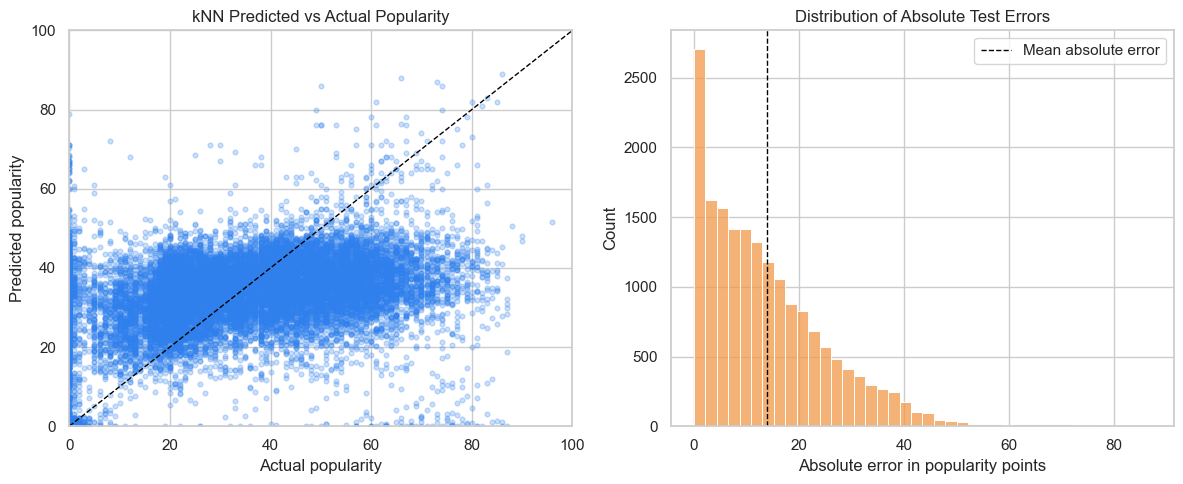

,actual_popularity,predicted_popularity,absolute_error
count,17948.00,17948.00,17948.00
mean,33.24,32.04,13.95
std,20.46,11.70,12.00
min,0.00,0.00,0.00
25%,19.00,27.38,4.59
50%,33.00,33.99,11.27
75%,49.00,39.19,20.40
max,96.00,89.00,87.00


In [11]:
evaluation = pd.DataFrame({
    'actual_popularity': y_test.values,
    'predicted_popularity': test_pred,
    'absolute_error': absolute_errors.values,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(evaluation['actual_popularity'], evaluation['predicted_popularity'], alpha=0.25, s=12, color='#2F80ED')
axes[0].plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1)
axes[0].set_title('kNN Predicted vs Actual Popularity')
axes[0].set_xlabel('Actual popularity')
axes[0].set_ylabel('Predicted popularity')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

sns.histplot(evaluation['absolute_error'], bins=40, ax=axes[1], color='#F2994A')
axes[1].axvline(evaluation['absolute_error'].mean(), color='black', linestyle='--', linewidth=1, label='Mean absolute error')
axes[1].set_title('Distribution of Absolute Test Errors')
axes[1].set_xlabel('Absolute error in popularity points')
axes[1].legend()

plt.tight_layout()
plt.show()

display(evaluation.describe().round(2))


## 7. Conclusion

The multiple-variable regression shows that the dataset variables have measurable relationships with popularity, especially genre-level differences and a few audio-feature effects. However, the numeric audio variables by themselves explain only a limited share of popularity.

The kNN regression improves over a mean-only baseline on the 20% test set, but its R² remains modest. This matches the broader lesson of the project: Spotify popularity is influenced by audio characteristics, but also by artist recognition, release timing, playlisting, marketing, and platform dynamics that are not fully captured in the Kaggle audio-feature columns.
